In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import gc
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


IMG_SIZE = 60
CHANNELS = 3
BATCH_SIZE = 32
NOISE_DIM = 256
EPOCHS = 2000

MAX_LEN = 20
VOCAB_SIZE = 5000
EMBED_DIM = 256

n_critic = 2

with open("./data/captions_60px.txt") as f:
    all_captions = [line.strip().split("|")[1] for line in f]

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)

embedding_layer = tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)

2025-04-30 16:57:59.043290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 16:57:59.060966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746012479.074877   61953 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746012479.078811   61953 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746012479.089353   61953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
def encode_caption(caption):
    seq = tokenizer.texts_to_sequences([caption.numpy().decode("utf-8")])[0]
    padded = pad_sequences([seq], maxlen=MAX_LEN)[0].astype(np.int32)
    return padded


def tf_encode_caption(caption):
    encoded = tf.py_function(encode_caption, inp=[caption], Tout=tf.int32)
    encoded.set_shape([MAX_LEN])
    return encoded


def load_image_caption_dataset(img_folder, caption_file):
    image_paths = []
    captions = []

    with open(caption_file, "r") as f:
        for line in f:
            img_name, caption = line.strip().split("|")
            image_paths.append(os.path.join(img_folder, img_name))
            captions.append(caption)

    def gen():
        for img_path, caption in zip(image_paths, captions):
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
            img = (tf.cast(img, tf.float32) / 127.5) - 1.0
            yield img, caption

    text_lstm = tf.keras.layers.LSTM(EMBED_DIM)

    def process(img, caption):
        encoded = tf_encode_caption(caption)
        embedded = embedding_layer(encoded)

        embedded = tf.expand_dims(embedded, 0)
        text_vector = text_lstm(embedded)
        text_vector = tf.squeeze(text_vector, 0)

        return img, text_vector

    dataset = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.string),
        ),
    )

    dataset = dataset.map(process)
    return (
        dataset.shuffle(1000)
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )

In [3]:
payload = load_image_caption_dataset("./data/image60px", "./data/captions_60px.txt")

2025-04-30 16:58:02.032752: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
class ConditioningAugmentation(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_mean = layers.Dense(embed_dim)
        self.dense_log_sigma = layers.Dense(embed_dim)

    def call(self, inputs):
        mean = self.dense_mean(inputs)
        log_sigma = self.dense_log_sigma(inputs)
        stddev = tf.exp(log_sigma)
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + stddev * epsilon

In [5]:
def make_generator():
    noise_input = tf.keras.Input(shape=(NOISE_DIM,))
    text_input = tf.keras.Input(shape=(EMBED_DIM,))

    ca = ConditioningAugmentation(EMBED_DIM)(text_input)
    x = layers.Concatenate()([noise_input, ca])

    x = layers.Dense(5 * 5 * 512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Reshape((5, 5, 512))(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)


    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

   
    x = layers.Resizing(60, 60)(x)
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(
        CHANNELS, kernel_size=3, padding="same", use_bias=False, activation="tanh"
    )(x)

    return tf.keras.Model([noise_input, text_input], x)


In [6]:
def make_discriminator():
    image_input = tf.keras.Input(shape=(60, 60, 3))
    text_input = tf.keras.Input(shape=(EMBED_DIM,))

    
    x = layers.Conv2D(64, 4, strides=2, padding="same")(image_input)
    x = layers.LeakyReLU()(x)

    
    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

   
    x = layers.Conv2D(512, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Flatten()(x)

    
    text_proj = layers.Dense(x.shape[-1], activation="relu")(text_input)
    ca_text = ConditioningAugmentation(x.shape[-1])(text_proj)

    
    x = layers.Concatenate()([x, ca_text])
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(1)(x)

    return tf.keras.Model([image_input, text_input], x)


In [7]:
for _ in range(n_critic):
    discriminator = make_discriminator()

generator = make_generator()


cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def generator_loss(fake_output):
    return -tf.reduce_mean(fake_output)


def discriminator_loss(real_output, fake_output):
    return tf.reduce_mean(tf.nn.relu(1.0 - real_output)) + tf.reduce_mean(
        tf.nn.relu(1.0 + fake_output)
    )


def gradient_penalty(discriminator, real_images, fake_images, text_embeddings):
    alpha = tf.random.uniform([real_images.shape[0], 1, 1, 1], 0.0, 1.0)
    interpolated_images = alpha * real_images + (1 - alpha) * fake_images
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        interpolated_output = discriminator(
            [interpolated_images, text_embeddings], training=True
        )
    grads = tape.gradient(interpolated_output, [interpolated_images])[0]
    penalty = tf.reduce_mean((tf.norm(grads, ord=2) - 1.0) ** 2)
    return penalty * 10


def add_noise(images, noise_factor=0.05):
    return images + noise_factor * tf.random.normal(shape=tf.shape(images))


gen_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5, beta_2=0.999)
disc_opt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)

In [8]:
@tf.function
def train_step(images, captions):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator([noise, captions], training=True)

        real_output = discriminator([images, captions], training=True)
        fake_output = discriminator([fake_images, captions], training=True)

        gp = gradient_penalty(discriminator, images, fake_images, captions)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output) + gp

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    gen_opt.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_opt.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [9]:
def save_generated_image(epoch):
    test_caption = "a foggy sky"
    seq = tokenizer.texts_to_sequences([test_caption])[0]
    padded = pad_sequences([seq], maxlen=MAX_LEN)
    padded_tensor = tf.constant(padded, dtype=tf.int32)

    noise = tf.random.normal([1, NOISE_DIM])

    embedding = embedding_layer(padded_tensor)
    embedding_mean = tf.reduce_mean(embedding, axis=1)

    generated = generator([noise, embedding_mean], training=False)
    img = (generated[0] + 1.0) / 2.0

    plt.imshow(img)
    plt.savefig(f"gen_images/generated_image_epoch_{epoch + 1}.png")
    plt.title(f"Epoch {epoch + 1}")
    plt.axis("off")
    plt.show()

In [10]:
checkpoint_dir = "./checkpoints"
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_60px")
checkpoint = tf.train.Checkpoint(
    generator=generator,
    discriminator=discriminator,
    g_optimizer=gen_opt,
    d_optimizer=disc_opt,
)

latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir)
if latest_ckpt:
    checkpoint.restore(latest_ckpt)
    print(f"Restored from checkpoint: {latest_ckpt}")
else:
    print("Starting training from scratch.")

Starting training from scratch.


In [11]:
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch, caption_batch in dataset:
            g_loss, d_loss = train_step(image_batch, caption_batch)

        print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            save_generated_image(epoch)

        if (epoch + 1) % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)


tf.config.optimizer.set_jit(True)
gc.collect()
tf.keras.backend.clear_session()

2025-04-30 16:59:23.432159: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1, Gen Loss: 0.2885, Disc Loss: 2.0342


2025-04-30 17:00:37.912185: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2, Gen Loss: 0.3484, Disc Loss: 2.4698
Epoch 3, Gen Loss: 0.4952, Disc Loss: 2.5702


2025-04-30 17:03:02.798197: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 4, Gen Loss: 0.4320, Disc Loss: 1.3340
Epoch 5, Gen Loss: 0.7769, Disc Loss: 1.5725
Epoch 6, Gen Loss: 0.3807, Disc Loss: 1.8818
Epoch 7, Gen Loss: 0.3889, Disc Loss: 1.8292


2025-04-30 17:07:48.273260: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 8, Gen Loss: -0.0074, Disc Loss: 1.8227
Epoch 9, Gen Loss: 1.2416, Disc Loss: 1.7568
Epoch 10, Gen Loss: 0.8394, Disc Loss: 1.4625


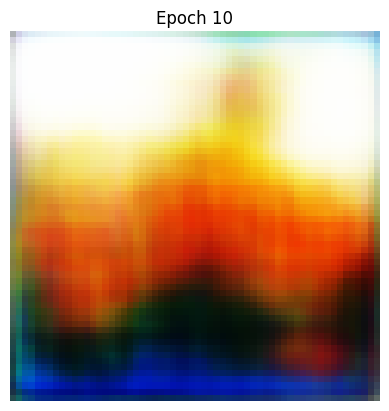

Epoch 11, Gen Loss: 0.5225, Disc Loss: 1.4037
Epoch 12, Gen Loss: 0.1273, Disc Loss: 1.3515
Epoch 13, Gen Loss: 0.3762, Disc Loss: 1.6784
Epoch 14, Gen Loss: 0.9394, Disc Loss: 1.4105
Epoch 15, Gen Loss: 0.4762, Disc Loss: 1.8222


2025-04-30 17:17:23.502637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 16, Gen Loss: 0.4987, Disc Loss: 1.5083
Epoch 17, Gen Loss: -0.2816, Disc Loss: 1.8520
Epoch 18, Gen Loss: 0.1336, Disc Loss: 1.5084
Epoch 19, Gen Loss: 0.5162, Disc Loss: 1.8995
Epoch 20, Gen Loss: 0.6419, Disc Loss: 1.5889


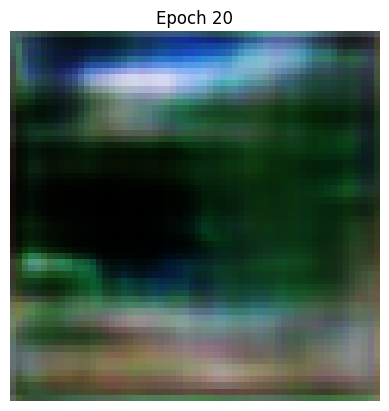

Epoch 21, Gen Loss: -0.1355, Disc Loss: 1.7524
Epoch 22, Gen Loss: 0.2423, Disc Loss: 1.7430
Epoch 23, Gen Loss: 0.7011, Disc Loss: 1.1612
Epoch 24, Gen Loss: 0.5570, Disc Loss: 1.5823
Epoch 25, Gen Loss: 0.3833, Disc Loss: 1.3197
Epoch 26, Gen Loss: 0.5779, Disc Loss: 1.2418
Epoch 27, Gen Loss: 0.2351, Disc Loss: 1.5398
Epoch 28, Gen Loss: 0.6672, Disc Loss: 1.5430
Epoch 29, Gen Loss: 0.5910, Disc Loss: 1.4532
Epoch 30, Gen Loss: 0.6131, Disc Loss: 1.1927


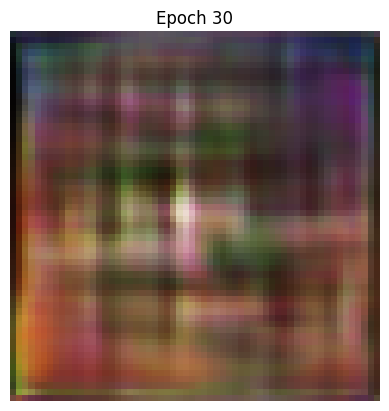

Epoch 31, Gen Loss: 1.1937, Disc Loss: 1.2388


In [ ]:
train(payload, EPOCHS)

In [ ]:
generator.save("generator_model_60px.keras")
discriminator.save("discriminator_model_60px.keras")